# Streaming flow policy in the Push-T environment
```{note}
*This notebook is adapted from [Diffusion policy's Colab notebook](https://colab.research.google.com/drive/1gxdkgRVfM55zihY9TFLja97cSVZOZq2B?usp=sharing) with an implementation of [Streaming flow policy](https://streaming-flow-policy.github.io/).*
```

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"  # 这一行会让程序只看得到 GPU 1

      Method  Guidance    CR    SR      AR  Safety
0  ccg-p-ode       2.0  34.3  61.0  0.9304   0.657
1  ccg-p-ode       4.0  17.1  74.3  0.9116   0.829
2  ccg-p-ode       6.0  10.5  72.4  0.8563   0.895
3  ccg-p-ode       7.0  12.4  69.5  0.8306   0.876
4  ccg-p-sde       1.0  55.8  37.5  0.8967   0.442


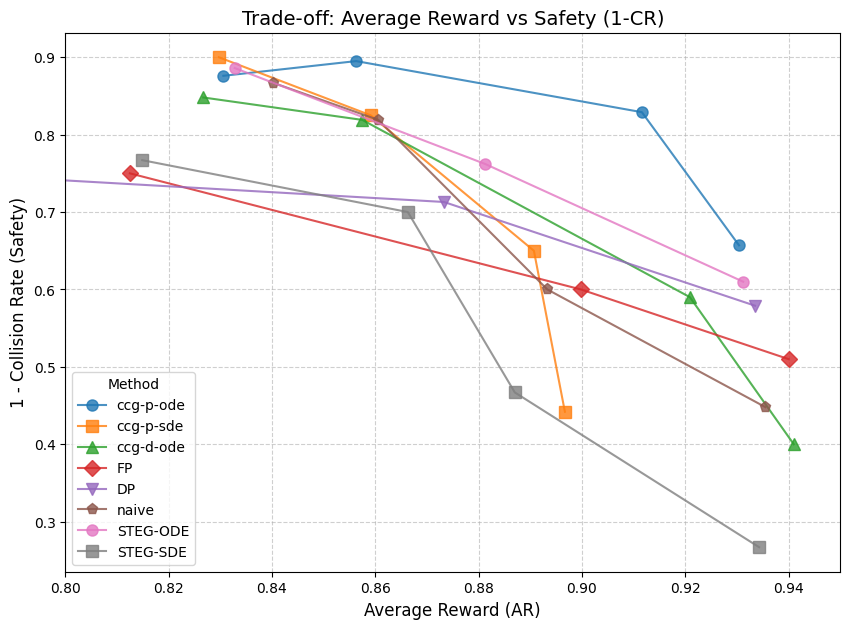

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the data
data = [
    # ccg-p-ode
    {'Method': 'ccg-p-ode', 'Guidance': 2, 'CR': 34.3, 'SR': 61.0, 'AR': 0.9304},
    {'Method': 'ccg-p-ode', 'Guidance': 4, 'CR': 17.1, 'SR': 74.3, 'AR': 0.9116},
    {'Method': 'ccg-p-ode', 'Guidance': 6, 'CR': 10.5, 'SR': 72.4, 'AR': 0.8563},
    {'Method': 'ccg-p-ode', 'Guidance': 7, 'CR': 12.4, 'SR': 69.5, 'AR': 0.8306},

    # # ccg-p-sde
    {'Method': 'ccg-p-sde', 'Guidance': 1, 'CR': 55.8, 'SR': 37.5, 'AR': 0.8967},
    {'Method': 'ccg-p-sde', 'Guidance': 2, 'CR': 35.0, 'SR': 56.7, 'AR': 0.8907},
    {'Method': 'ccg-p-sde', 'Guidance': 5, 'CR': 17.5, 'SR': 67.5, 'AR': 0.8591},
    # {'Method': 'ccg-p-sde', 'Guidance': 7, 'CR': 15.8, 'SR': 72.5, 'AR': 0.8595},
    {'Method': 'ccg-p-sde', 'Guidance': 9, 'CR': 10.0, 'SR': 71.7, 'AR': 0.8297},

    # ccg-d-ode
    {'Method': 'ccg-d-ode', 'Guidance': 0.2, 'CR': 60.0, 'SR': 35.2, 'AR': 0.9410},
    {'Method': 'ccg-d-ode', 'Guidance': 0.6, 'CR': 41.0, 'SR': 52.4, 'AR': 0.9209},
    {'Method': 'ccg-d-ode', 'Guidance': 1.7, 'CR': 18.1, 'SR': 65.7, 'AR': 0.8575},
    {'Method': 'ccg-d-ode', 'Guidance': 2.5, 'CR': 15.2, 'SR': 63.8, 'AR': 0.8267},

    # FP
    {'Method': 'FP', 'Guidance': 0.5, 'CR': 49.0, 'SR': 47.0, 'AR': 0.9400},
    {'Method': 'FP', 'Guidance': 0.7, 'CR': 40.0, 'SR': 49.0, 'AR': 0.8998},
    {'Method': 'FP', 'Guidance': 1, 'CR': 25.0, 'SR': 56.0, 'AR': 0.8125},
    # {'Method': 'FP', 'Guidance': 1.2, 'CR': 16.0, 'SR': 53.0, 'AR': 0.7190},

    # DP
    {'Method': 'DP', 'Guidance': 10, 'CR': 42.1, 'SR': 57.9, 'AR': 0.9335},
    {'Method': 'DP', 'Guidance': 15, 'CR': 28.7, 'SR': 58.5, 'AR': 0.8733},
    {'Method': 'DP', 'Guidance': 20, 'CR': 24.5, 'SR': 47.9, 'AR': 0.7628},

    # # naive
    {'Method': 'naive', 'Guidance': 2, 'CR': 55.2, 'SR': 43.8, 'AR': 0.9355},
    {'Method': 'naive', 'Guidance': 3, 'CR': 40.0, 'SR': 52.4, 'AR': 0.8933},
    # {'Method': 'naive', 'Guidance': 6, 'CR': 16.2, 'SR': 68.6, 'AR': 0.8624},
    {'Method': 'naive', 'Guidance': 8, 'CR': 18.1, 'SR': 66.7, 'AR': 0.8606},
    {'Method': 'naive', 'Guidance': 10, 'CR': 13.3, 'SR': 67.6, 'AR': 0.8402},

    # STEG-ODE
    {'Method': 'STEG-ODE', 'Guidance': 3, 'CR': 39.0, 'SR': 53.3, 'AR': 0.9312},
    {'Method': 'STEG-ODE', 'Guidance': 5, 'CR': 23.8, 'SR': 64.8, 'AR': 0.8813},
    {'Method': 'STEG-ODE', 'Guidance': 7, 'CR': 11.4, 'SR': 66.7, 'AR': 0.8328},
    # {'Method': 'STEG-ODE', 'Guidance': 10, 'CR': 14.3, 'SR': 61.9, 'AR': 0.8063},
    # {'Method': 'STEG-ODE', 'Guidance': 12, 'CR': 10.5, 'SR': 61.9, 'AR': 0.7768},

    # # STEG-SDE
    {'Method': 'STEG-SDE', 'Guidance': 1, 'CR': 73.3, 'SR': 22.5, 'AR': 0.9343},
    {'Method': 'STEG-SDE', 'Guidance': 3, 'CR': 53.3, 'SR': 40.0, 'AR': 0.8870},
    {'Method': 'STEG-SDE', 'Guidance': 5, 'CR': 30.0, 'SR': 56.7, 'AR': 0.8663},
    {'Method': 'STEG-SDE', 'Guidance': 10, 'CR': 23.3, 'SR': 59.2, 'AR': 0.8149},
    # {'Method': 'STEG-SDE', 'Guidance': 12, 'CR': 23.3, 'SR': 50.8, 'AR': 0.7856}
]

df = pd.DataFrame(data)
df['Safety'] = 1 - (df['CR'] / 100) # Calculate 1 - CR

# Export to CSV for the user
df.to_csv('experiment_data.csv', index=False)

# 2. Plotting
plt.figure(figsize=(10, 7))
methods = df['Method'].unique()
markers = ['o', 's', '^', 'D', 'v', 'p']

for i, method in enumerate(methods):
    subset = df[df['Method'] == method].sort_values('Guidance')
    plt.plot(subset['AR'], subset['Safety'], 
             marker=markers[i % len(markers)], 
             label=method, 
             linestyle='-', 
             markersize=8,
             alpha=0.8)

plt.xlim(0.80, 0.95)  # 限制横轴范围，0.95可以根据你数据的最大值微调
# 如果你想让纵轴也更聚焦，可以取消下面这行的注释
# plt.ylim(0.75, 1.0)

plt.xlabel('Average Reward (AR)', fontsize=12)
plt.ylabel('1 - Collision Rate (Safety)', fontsize=12)
plt.title('Trade-off: Average Reward vs Safety (1-CR)', fontsize=14)
plt.legend(title='Method', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Invert X axis? Usually higher reward is better, higher safety is better.
# The user asked for a trade-off. Usually trade-off implies one goes up, other goes down.
# Let's keep axes normal (increasing). 
# Higher AR (right) is better. Higher Safety (up) is better.
# The ideal point is top-right.

plt.savefig('tradeoff_plot.png')
print(df.head())

成功注册本地 Arial 字体！


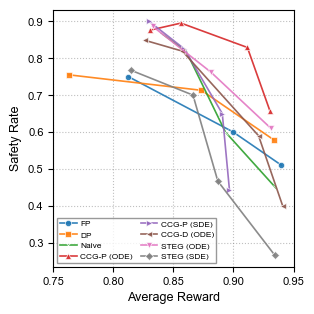

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.ticker as ticker

# ------------------------------------------------------------------
# 1. 核心修复步骤：直接把 ttf 文件注册进 Matplotlib (保持你的原逻辑)
# ------------------------------------------------------------------
font_path = 'arial.ttf'  # 确保这个文件在你的目录下

try:
    # 这一步把你的文件加入到 Matplotlib 的已知字体列表中
    font_manager.fontManager.addfont(font_path)
    
    # 此时，Matplotlib 已经认识 "Arial" 了
    plt.rcParams['font.family'] = 'Arial'
    print("成功注册本地 Arial 字体！")
except Exception as e:
    print(f"加载字体失败: {e}")
    print("回退到默认字体...")
    plt.rcParams['font.family'] = 'sans-serif'

# ------------------------------------------------------------------
# 2. 设置 RAL 风格 (全局设置)
# ------------------------------------------------------------------
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 6  # 因为图例项变多了，稍微调小一点以适应小图
plt.rcParams['lines.linewidth'] = 1.2
plt.rcParams['lines.markersize'] = 4.5

# ------------------------------------------------------------------
# 3. Data Preparation
# ------------------------------------------------------------------
data = [
    # ccg-p-ode
    {'Method': 'ccg-p-ode', 'Guidance': 2, 'CR': 34.3, 'SR': 61.0, 'AR': 0.9304},
    {'Method': 'ccg-p-ode', 'Guidance': 4, 'CR': 17.1, 'SR': 74.3, 'AR': 0.9116},
    {'Method': 'ccg-p-ode', 'Guidance': 6, 'CR': 10.5, 'SR': 72.4, 'AR': 0.8563},
    {'Method': 'ccg-p-ode', 'Guidance': 7, 'CR': 12.4, 'SR': 69.5, 'AR': 0.8306},

    # ccg-p-sde
    {'Method': 'ccg-p-sde', 'Guidance': 1, 'CR': 55.8, 'SR': 37.5, 'AR': 0.8967},
    {'Method': 'ccg-p-sde', 'Guidance': 2, 'CR': 35.0, 'SR': 56.7, 'AR': 0.8907},
    {'Method': 'ccg-p-sde', 'Guidance': 5, 'CR': 17.5, 'SR': 67.5, 'AR': 0.8591},
    {'Method': 'ccg-p-sde', 'Guidance': 9, 'CR': 10.0, 'SR': 71.7, 'AR': 0.8297},

    # ccg-d-ode
    {'Method': 'ccg-d-ode', 'Guidance': 0.2, 'CR': 60.0, 'SR': 35.2, 'AR': 0.9410},
    {'Method': 'ccg-d-ode', 'Guidance': 0.6, 'CR': 41.0, 'SR': 52.4, 'AR': 0.9209},
    {'Method': 'ccg-d-ode', 'Guidance': 1.7, 'CR': 18.1, 'SR': 65.7, 'AR': 0.8575},
    {'Method': 'ccg-d-ode', 'Guidance': 2.5, 'CR': 15.2, 'SR': 63.8, 'AR': 0.8267},

    # FP
    {'Method': 'FP', 'Guidance': 0.5, 'CR': 49.0, 'SR': 47.0, 'AR': 0.9400},
    {'Method': 'FP', 'Guidance': 0.7, 'CR': 40.0, 'SR': 49.0, 'AR': 0.8998},
    {'Method': 'FP', 'Guidance': 1, 'CR': 25.0, 'SR': 56.0, 'AR': 0.8125},
    # {'Method': 'FP', 'Guidance': 1.2, 'CR': 16.0, 'SR': 53.0, 'AR': 0.7190}, # Outlier

    # DP
    {'Method': 'DP', 'Guidance': 10, 'CR': 42.1, 'SR': 57.9, 'AR': 0.9335},
    {'Method': 'DP', 'Guidance': 15, 'CR': 28.7, 'SR': 58.5, 'AR': 0.8733},
    {'Method': 'DP', 'Guidance': 20, 'CR': 24.5, 'SR': 47.9, 'AR': 0.7628},

    # naive
    {'Method': 'naive', 'Guidance': 2, 'CR': 55.2, 'SR': 43.8, 'AR': 0.9355},
    {'Method': 'naive', 'Guidance': 3, 'CR': 40.0, 'SR': 52.4, 'AR': 0.8933},
    {'Method': 'naive', 'Guidance': 8, 'CR': 18.1, 'SR': 66.7, 'AR': 0.8606},
    {'Method': 'naive', 'Guidance': 10, 'CR': 13.3, 'SR': 67.6, 'AR': 0.8402},

    # STEG-ODE
    {'Method': 'STEG-ODE', 'Guidance': 3, 'CR': 39.0, 'SR': 53.3, 'AR': 0.9312},
    {'Method': 'STEG-ODE', 'Guidance': 5, 'CR': 23.8, 'SR': 64.8, 'AR': 0.8813},
    {'Method': 'STEG-ODE', 'Guidance': 7, 'CR': 11.4, 'SR': 66.7, 'AR': 0.8328},

    # STEG-SDE
    {'Method': 'STEG-SDE', 'Guidance': 1, 'CR': 73.3, 'SR': 22.5, 'AR': 0.9343},
    {'Method': 'STEG-SDE', 'Guidance': 3, 'CR': 53.3, 'SR': 40.0, 'AR': 0.8870},
    {'Method': 'STEG-SDE', 'Guidance': 5, 'CR': 30.0, 'SR': 56.7, 'AR': 0.8663},
    {'Method': 'STEG-SDE', 'Guidance': 10, 'CR': 23.3, 'SR': 59.2, 'AR': 0.8149},
]

df = pd.DataFrame(data)
df['Safety'] = 1 - (df['CR'] / 100)

# Export to CSV if needed
# df.to_csv('experiment_data.csv', index=False)

# ------------------------------------------------------------------
# 4. Plotting
# ------------------------------------------------------------------
# 使用 RAL 标准单栏宽度 (约 3.3 英寸)，保持紧凑
plt.figure(figsize=(3, 3)) 

# 定义顺序和标签映射
method_order = [
    'FP', 'DP', 'naive', 
    'ccg-p-ode', 'ccg-p-sde', 'ccg-d-ode',
    'STEG-ODE', 'STEG-SDE'
]

label_map = {
    'FP': 'FP',
    'DP': 'DP',
    'naive': 'Naive',
    'ccg-p-ode': 'CCG-P (ODE)',
    'ccg-p-sde': 'CCG-P (SDE)',
    'ccg-d-ode': 'CCG-D (ODE)',
    'STEG-ODE': 'STEG (ODE)',
    'STEG-SDE': 'STEG (SDE)'
}

# 扩展 Marker 列表以区分8种方法
markers = {
    'FP': 'o', 
    'DP': 's', 
    'naive': 'x',
    'ccg-p-ode': '^', 
    'ccg-p-sde': '>', 
    'ccg-d-ode': '<',
    'STEG-ODE': 'v', 
    'STEG-SDE': 'D'
}

for method_key in method_order:
    subset = df[df['Method'] == method_key].sort_values('Guidance')
    
    if subset.empty:
        continue

    plt.plot(subset['AR'], subset['Safety'], 
             marker=markers.get(method_key, 'o'), 
             label=label_map.get(method_key, method_key), 
             linestyle='-', 
             alpha=0.9,
             markeredgewidth=0.5,
             markeredgecolor='white') # 增加白边让点更清晰

# Axis Range
# 由于新数据的 AR 范围较大 (DP低至0.76)，需要调整 X 轴
plt.xlim(0.75, 0.95) 

plt.xlabel('Average Reward')
plt.ylabel('Safety Rate')

# Grid Style (Dots, Light Gray)
plt.grid(True, linestyle=':', alpha=0.5, color='gray')

# Legend Style
# 由于图例很多，使用 ncol=2 分两列显示，放在左下角
plt.legend(loc='lower left', framealpha=0.8, edgecolor='gray', fancybox=False, 
           ncol=2, columnspacing=1.0, handletextpad=0.4, borderpad=0.3)

plt.tight_layout(pad=0.2)
plt.savefig('tradeoff_plot_unified.pdf', format='pdf', bbox_inches='tight')
plt.savefig('tradeoff_plot_unified.png', dpi=300, bbox_inches='tight')
plt.show()

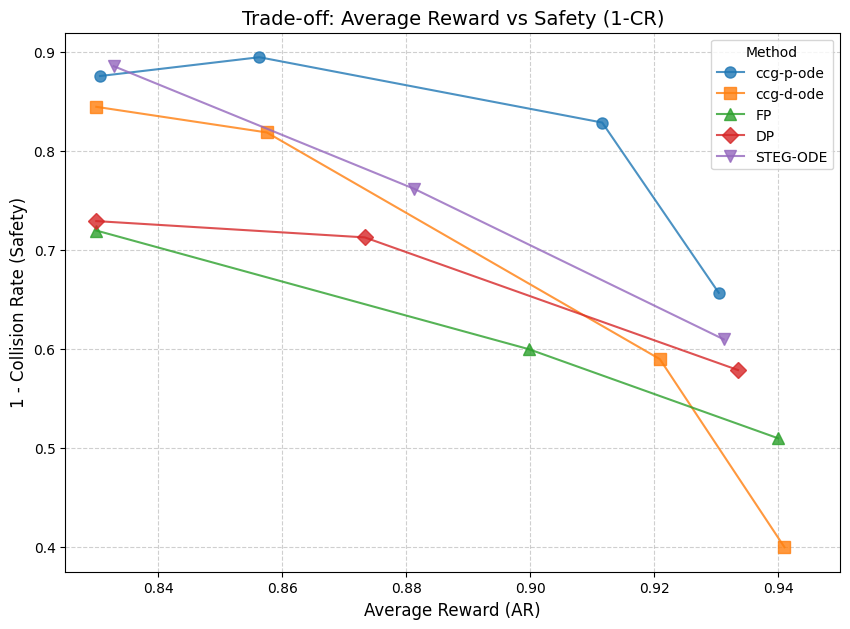

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the data
data = [
    # ccg-p-ode
    {'Method': 'ccg-p-ode', 'Guidance': 2, 'CR': 34.3, 'SR': 61.0, 'AR': 0.9304},
    {'Method': 'ccg-p-ode', 'Guidance': 4, 'CR': 17.1, 'SR': 74.3, 'AR': 0.9116},
    {'Method': 'ccg-p-ode', 'Guidance': 6, 'CR': 10.5, 'SR': 72.4, 'AR': 0.8563},
    {'Method': 'ccg-p-ode', 'Guidance': 7, 'CR': 12.4, 'SR': 69.5, 'AR': 0.8306},

    # ccg-d-ode
    {'Method': 'ccg-d-ode', 'Guidance': 0.2, 'CR': 60.0, 'SR': 35.2, 'AR': 0.9410},
    {'Method': 'ccg-d-ode', 'Guidance': 0.6, 'CR': 41.0, 'SR': 52.4, 'AR': 0.9209},
    {'Method': 'ccg-d-ode', 'Guidance': 1.7, 'CR': 18.1, 'SR': 65.7, 'AR': 0.8575},
    {'Method': 'ccg-d-ode', 'Guidance': 2.5, 'CR': 15.2, 'SR': 63.8, 'AR': 0.8267}, # Will be truncated

    # FP
    {'Method': 'FP', 'Guidance': 0.5, 'CR': 49.0, 'SR': 47.0, 'AR': 0.9400},
    {'Method': 'FP', 'Guidance': 0.7, 'CR': 40.0, 'SR': 49.0, 'AR': 0.8998},
    {'Method': 'FP', 'Guidance': 1, 'CR': 25.0, 'SR': 56.0, 'AR': 0.8125}, # Will be truncated
    {'Method': 'FP', 'Guidance': 1.2, 'CR': 16.0, 'SR': 53.0, 'AR': 0.7190},

    # DP
    {'Method': 'DP', 'Guidance': 10, 'CR': 42.1, 'SR': 57.9, 'AR': 0.9335},
    {'Method': 'DP', 'Guidance': 15, 'CR': 28.7, 'SR': 58.5, 'AR': 0.8733},
    {'Method': 'DP', 'Guidance': 20, 'CR': 24.5, 'SR': 47.9, 'AR': 0.7628}, # Will be truncated

    # STEG-ODE
    {'Method': 'STEG-ODE', 'Guidance': 3, 'CR': 39.0, 'SR': 53.3, 'AR': 0.9312},
    {'Method': 'STEG-ODE', 'Guidance': 5, 'CR': 23.8, 'SR': 64.8, 'AR': 0.8813},
    {'Method': 'STEG-ODE', 'Guidance': 7, 'CR': 11.4, 'SR': 66.7, 'AR': 0.8328},
]

df = pd.DataFrame(data)
df['Safety'] = 1 - (df['CR'] / 100) # Calculate 1 - CR

# Export to CSV for the user
df.to_csv('experiment_data.csv', index=False)

# 2. Plotting
plt.figure(figsize=(10, 7))
methods = df['Method'].unique()
markers = ['o', 's', '^', 'D', 'v', 'p']

# 设定截断目标 x 值 (根据你之前的xlim是0.83)
TARGET_X = 0.83 

for i, method in enumerate(methods):
    subset = df[df['Method'] == method].sort_values('Guidance')
    
    # 获取原始数据
    x_raw = subset['AR'].values
    y_raw = subset['Safety'].values
    
    plot_x = []
    plot_y = []
    
    # 数据处理：计算插值并截断
    # 逻辑：遍历线段，保留 >= 0.83 的部分，如果线段穿过 0.83，则计算交点
    
    # 1. 如果第一个点就在范围内，先加入
    if len(x_raw) > 0 and x_raw[0] >= TARGET_X:
        plot_x.append(x_raw[0])
        plot_y.append(y_raw[0])
        
    for k in range(len(x_raw) - 1):
        x1, y1 = x_raw[k], y_raw[k]
        x2, y2 = x_raw[k+1], y_raw[k+1]
        
        # 判断当前线段是否穿过 Target X
        # 情况：一个点在右边(>=0.83)，一个点在左边(<0.83)
        crosses = (x1 >= TARGET_X > x2) or (x1 < TARGET_X <= x2)
        
        if crosses:
            # 线性插值公式: y = y1 + slope * (x_target - x1)
            slope = (y2 - y1) / (x2 - x1)
            y_interp = y1 + slope * (TARGET_X - x1)
            
            # 加入插值点 (截断点)
            plot_x.append(TARGET_X)
            plot_y.append(y_interp)
        
        # 如果第二个点在范围内，加入它
        if x2 >= TARGET_X:
            plot_x.append(x2)
            plot_y.append(y2)

    # 绘制处理后的数据
    plt.plot(plot_x, plot_y, 
             marker=markers[i % len(markers)], 
             label=method, 
             linestyle='-', 
             markersize=8,
             alpha=0.8)

# 这里设置 0.83 为左边界，所有线条现在应该正好贴在这个边界上
plt.xlim(0.825, 0.95) 

plt.xlabel('Average Reward (AR)', fontsize=12)
plt.ylabel('1 - Collision Rate (Safety)', fontsize=12)
plt.title('Trade-off: Average Reward vs Safety (1-CR)', fontsize=14)
plt.legend(title='Method', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('tradeoff_plot_fixed.png')
plt.show()

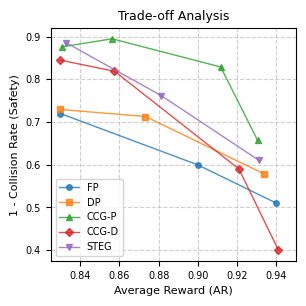

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the data
data = [
    # ccg-p-ode
    {'Method': 'ccg-p-ode', 'Guidance': 2, 'CR': 34.3, 'SR': 61.0, 'AR': 0.9304},
    {'Method': 'ccg-p-ode', 'Guidance': 4, 'CR': 17.1, 'SR': 74.3, 'AR': 0.9116},
    {'Method': 'ccg-p-ode', 'Guidance': 6, 'CR': 10.5, 'SR': 72.4, 'AR': 0.8563},
    {'Method': 'ccg-p-ode', 'Guidance': 7, 'CR': 12.4, 'SR': 69.5, 'AR': 0.8306},

    # ccg-d-ode
    {'Method': 'ccg-d-ode', 'Guidance': 0.2, 'CR': 60.0, 'SR': 35.2, 'AR': 0.9410},
    {'Method': 'ccg-d-ode', 'Guidance': 0.6, 'CR': 41.0, 'SR': 52.4, 'AR': 0.9209},
    {'Method': 'ccg-d-ode', 'Guidance': 1.7, 'CR': 18.1, 'SR': 65.7, 'AR': 0.8575},
    {'Method': 'ccg-d-ode', 'Guidance': 2.5, 'CR': 15.2, 'SR': 63.8, 'AR': 0.8267},

    # FP
    {'Method': 'FP', 'Guidance': 0.5, 'CR': 49.0, 'SR': 47.0, 'AR': 0.9400},
    {'Method': 'FP', 'Guidance': 0.7, 'CR': 40.0, 'SR': 49.0, 'AR': 0.8998},
    {'Method': 'FP', 'Guidance': 1, 'CR': 25.0, 'SR': 56.0, 'AR': 0.8125},
    {'Method': 'FP', 'Guidance': 1.2, 'CR': 16.0, 'SR': 53.0, 'AR': 0.7190},

    # DP
    {'Method': 'DP', 'Guidance': 10, 'CR': 42.1, 'SR': 57.9, 'AR': 0.9335},
    {'Method': 'DP', 'Guidance': 15, 'CR': 28.7, 'SR': 58.5, 'AR': 0.8733},
    {'Method': 'DP', 'Guidance': 20, 'CR': 24.5, 'SR': 47.9, 'AR': 0.7628},

    # STEG-ODE
    {'Method': 'STEG-ODE', 'Guidance': 3, 'CR': 39.0, 'SR': 53.3, 'AR': 0.9312},
    {'Method': 'STEG-ODE', 'Guidance': 5, 'CR': 23.8, 'SR': 64.8, 'AR': 0.8813},
    {'Method': 'STEG-ODE', 'Guidance': 7, 'CR': 11.4, 'SR': 66.7, 'AR': 0.8328},
]

df = pd.DataFrame(data)
df['Safety'] = 1 - (df['CR'] / 100)

# 2. Plotting
# 修改点 1：Figure size 改为 3, 3
plt.figure(figsize=(3, 3))

# 修改点 2：定义指定的顺序和标签映射
method_order = ['FP', 'DP', 'ccg-p-ode', 'ccg-d-ode', 'STEG-ODE']
label_map = {
    'FP': 'FP',
    'DP': 'DP',
    'ccg-p-ode': 'CCG-P',
    'ccg-d-ode': 'CCG-D',
    'STEG-ODE': 'STEG'
}
markers = ['o', 's', '^', 'D', 'v'] # 对应上面的顺序

TARGET_X = 0.83 

# 按照指定的 method_order 遍历
for i, method_key in enumerate(method_order):
    subset = df[df['Method'] == method_key].sort_values('Guidance')
    
    if subset.empty:
        continue

    x_raw = subset['AR'].values
    y_raw = subset['Safety'].values
    
    plot_x = []
    plot_y = []
    
    # 插值逻辑
    if len(x_raw) > 0 and x_raw[0] >= TARGET_X:
        plot_x.append(x_raw[0])
        plot_y.append(y_raw[0])
        
    for k in range(len(x_raw) - 1):
        x1, y1 = x_raw[k], y_raw[k]
        x2, y2 = x_raw[k+1], y_raw[k+1]
        
        crosses = (x1 >= TARGET_X > x2) or (x1 < TARGET_X <= x2)
        
        if crosses:
            slope = (y2 - y1) / (x2 - x1)
            y_interp = y1 + slope * (TARGET_X - x1)
            plot_x.append(TARGET_X)
            plot_y.append(y_interp)
        
        if x2 >= TARGET_X:
            plot_x.append(x2)
            plot_y.append(y2)

    # 绘制
    plt.plot(plot_x, plot_y, 
             marker=markers[i], 
             label=label_map[method_key], # 使用映射后的标签
             linestyle='-', 
             markersize=4,   # 缩小 marker 以适应小图
             linewidth=1,    # 缩小线宽
             alpha=0.8)

plt.xlim(0.825, 0.95) 

# 字体调整：因为图很小(3x3)，字号需要相应调小
plt.xlabel('Average Reward (AR)', fontsize=8)
plt.ylabel('1 - Collision Rate (Safety)', fontsize=8)
plt.title('Trade-off Analysis', fontsize=9)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=7)

# Legend 调整
plt.legend(fontsize=7, frameon=True, loc='best')

plt.tight_layout(pad=0.5) # 减少留白
plt.savefig('tradeoff_plot_small.png', dpi=300)
plt.show()

成功注册本地 Arial 字体！不再需要手动传参。


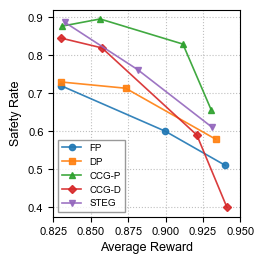

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ------------------------------------------------------------------
# 核心修复步骤：直接把 ttf 文件注册进 Matplotlib
# ------------------------------------------------------------------
font_path = 'arial.ttf'  # 确保这个文件在你的目录下

try:
    # 1. 这一步把你的文件加入到 Matplotlib 的已知字体列表中
    font_manager.fontManager.addfont(font_path)
    
    # 2. 此时，Matplotlib 已经认识 "Arial" 了 (注意：addfont会自动识别字体内部名为Arial)
    # 我们直接设置全局字体，这样所有地方都会自动变成 Arial
    plt.rcParams['font.family'] = 'Arial'
    
    print("成功注册本地 Arial 字体！不再需要手动传参。")
except Exception as e:
    print(f"加载字体失败: {e}")
    print("回退到默认字体...")
    plt.rcParams['font.family'] = 'sans-serif'
# ------------------------------------------------------------------
# 2. 设置 RAL 风格 (全局设置在这里可能不生效，所以我们在后面绘图时手动指定 fontproperties)
# ------------------------------------------------------------------
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 7
plt.rcParams['lines.linewidth'] = 1.2
plt.rcParams['lines.markersize'] = 4.5

# 1. Prepare the data
data = [
    # ccg-p-ode
    {'Method': 'ccg-p-ode', 'Guidance': 2, 'CR': 34.3, 'SR': 61.0, 'AR': 0.9304},
    {'Method': 'ccg-p-ode', 'Guidance': 4, 'CR': 17.1, 'SR': 74.3, 'AR': 0.9116},
    {'Method': 'ccg-p-ode', 'Guidance': 6, 'CR': 10.5, 'SR': 72.4, 'AR': 0.8563},
    {'Method': 'ccg-p-ode', 'Guidance': 7, 'CR': 12.4, 'SR': 69.5, 'AR': 0.8306},

    # ccg-d-ode
    {'Method': 'ccg-d-ode', 'Guidance': 0.2, 'CR': 60.0, 'SR': 35.2, 'AR': 0.9410},
    {'Method': 'ccg-d-ode', 'Guidance': 0.6, 'CR': 41.0, 'SR': 52.4, 'AR': 0.9209},
    {'Method': 'ccg-d-ode', 'Guidance': 1.7, 'CR': 18.1, 'SR': 65.7, 'AR': 0.8575},
    {'Method': 'ccg-d-ode', 'Guidance': 2.5, 'CR': 15.2, 'SR': 63.8, 'AR': 0.8267},

    # FP
    {'Method': 'FP', 'Guidance': 0.5, 'CR': 49.0, 'SR': 47.0, 'AR': 0.9400},
    {'Method': 'FP', 'Guidance': 0.7, 'CR': 40.0, 'SR': 49.0, 'AR': 0.8998},
    {'Method': 'FP', 'Guidance': 1, 'CR': 25.0, 'SR': 56.0, 'AR': 0.8125},
    {'Method': 'FP', 'Guidance': 1.2, 'CR': 16.0, 'SR': 53.0, 'AR': 0.7190},

    # DP
    {'Method': 'DP', 'Guidance': 10, 'CR': 42.1, 'SR': 57.9, 'AR': 0.9335},
    {'Method': 'DP', 'Guidance': 15, 'CR': 28.7, 'SR': 58.5, 'AR': 0.8733},
    {'Method': 'DP', 'Guidance': 20, 'CR': 24.5, 'SR': 47.9, 'AR': 0.7628},

    # STEG-ODE
    {'Method': 'STEG-ODE', 'Guidance': 3, 'CR': 39.0, 'SR': 53.3, 'AR': 0.9312},
    {'Method': 'STEG-ODE', 'Guidance': 5, 'CR': 23.8, 'SR': 64.8, 'AR': 0.8813},
    {'Method': 'STEG-ODE', 'Guidance': 7, 'CR': 11.4, 'SR': 66.7, 'AR': 0.8328},
]

df = pd.DataFrame(data)
df['Safety'] = 1 - (df['CR'] / 100)

# 2. Plotting
plt.figure(figsize=(2.5, 2.5)) # RAL 单栏宽度通常在 3.3-3.5 英寸左右，3x3 很合适

method_order = ['FP', 'DP', 'ccg-p-ode', 'ccg-d-ode', 'STEG-ODE']
label_map = {
    'FP': 'FP',
    'DP': 'DP',
    'ccg-p-ode': 'CCG-P',
    'ccg-d-ode': 'CCG-D',
    'STEG-ODE': 'STEG'
}
markers = ['o', 's', '^', 'D', 'v']

TARGET_X = 0.83 

for i, method_key in enumerate(method_order):
    subset = df[df['Method'] == method_key].sort_values('Guidance')
    
    if subset.empty:
        continue

    x_raw = subset['AR'].values
    y_raw = subset['Safety'].values
    
    plot_x = []
    plot_y = []
    
    # 插值逻辑
    if len(x_raw) > 0 and x_raw[0] >= TARGET_X:
        plot_x.append(x_raw[0])
        plot_y.append(y_raw[0])
        
    for k in range(len(x_raw) - 1):
        x1, y1 = x_raw[k], y_raw[k]
        x2, y2 = x_raw[k+1], y_raw[k+1]
        
        crosses = (x1 >= TARGET_X > x2) or (x1 < TARGET_X <= x2)
        
        if crosses:
            slope = (y2 - y1) / (x2 - x1)
            y_interp = y1 + slope * (TARGET_X - x1)
            plot_x.append(TARGET_X)
            plot_y.append(y_interp)
        
        if x2 >= TARGET_X:
            plot_x.append(x2)
            plot_y.append(y2)

    plt.plot(plot_x, plot_y, 
             marker=markers[i], 
             label=label_map[method_key], 
             linestyle='-', 
             alpha=0.9) # 增加一点不透明度，使颜色更实

plt.xlim(0.825, 0.95) 

plt.xlabel('Average Reward')         # RAL 风格通常直接写变量名，不需要 (AR) 除非你需要缩写
plt.ylabel('Safety Rate')            # 简化 Label，或者用 'Safety (1 - CR)'

# 移除 Title，因为学术论文通常在 Figure Caption 中写标题
# plt.title('Trade-off Analysis') 

plt.grid(True, linestyle=':', alpha=0.5, color='gray') # 使用更细的网格

# Legend 放在左下角或其他空旷处，去掉边框看起来更干净（可选，这里保留边框但设为透明背景）
plt.legend(loc='best', framealpha=0.8, edgecolor='gray', fancybox=False)

plt.tight_layout(pad=0.2)
plt.savefig('tradeoff_plot_ral_arial.pdf', format='pdf', bbox_inches='tight')
plt.savefig('tradeoff_plot_ral_arial.png', dpi=300, bbox_inches='tight')
plt.show()

成功注册本地 Arial 字体！不再需要手动传参。


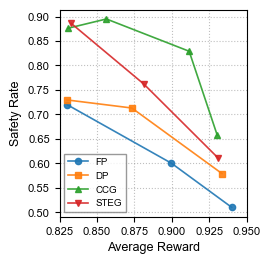

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ------------------------------------------------------------------
# 核心修复步骤：直接把 ttf 文件注册进 Matplotlib
# ------------------------------------------------------------------
font_path = 'arial.ttf'  # 确保这个文件在你的目录下

try:
    # 1. 这一步把你的文件加入到 Matplotlib 的已知字体列表中
    font_manager.fontManager.addfont(font_path)
    
    # 2. 此时，Matplotlib 已经认识 "Arial" 了 (注意：addfont会自动识别字体内部名为Arial)
    # 我们直接设置全局字体，这样所有地方都会自动变成 Arial
    plt.rcParams['font.family'] = 'Arial'
    
    print("成功注册本地 Arial 字体！不再需要手动传参。")
except Exception as e:
    print(f"加载字体失败: {e}")
    print("回退到默认字体...")
    plt.rcParams['font.family'] = 'sans-serif'
# ------------------------------------------------------------------
# 2. 设置 RAL 风格 (全局设置在这里可能不生效，所以我们在后面绘图时手动指定 fontproperties)
# ------------------------------------------------------------------
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 7
plt.rcParams['lines.linewidth'] = 1.2
plt.rcParams['lines.markersize'] = 4.5

# 1. Prepare the data
data = [
    # ccg-p-ode
    {'Method': 'ccg-p-ode', 'Guidance': 2, 'CR': 34.3, 'SR': 61.0, 'AR': 0.9304},
    {'Method': 'ccg-p-ode', 'Guidance': 4, 'CR': 17.1, 'SR': 74.3, 'AR': 0.9116},
    {'Method': 'ccg-p-ode', 'Guidance': 6, 'CR': 10.5, 'SR': 72.4, 'AR': 0.8563},
    {'Method': 'ccg-p-ode', 'Guidance': 7, 'CR': 12.4, 'SR': 69.5, 'AR': 0.8306},

    # ccg-d-ode
    {'Method': 'ccg-d-ode', 'Guidance': 0.2, 'CR': 60.0, 'SR': 35.2, 'AR': 0.9410},
    {'Method': 'ccg-d-ode', 'Guidance': 0.6, 'CR': 41.0, 'SR': 52.4, 'AR': 0.9209},
    {'Method': 'ccg-d-ode', 'Guidance': 1.7, 'CR': 18.1, 'SR': 65.7, 'AR': 0.8575},
    {'Method': 'ccg-d-ode', 'Guidance': 2.5, 'CR': 15.2, 'SR': 63.8, 'AR': 0.8267},

    # FP
    {'Method': 'FP', 'Guidance': 0.5, 'CR': 49.0, 'SR': 47.0, 'AR': 0.9400},
    {'Method': 'FP', 'Guidance': 0.7, 'CR': 40.0, 'SR': 49.0, 'AR': 0.8998},
    {'Method': 'FP', 'Guidance': 1, 'CR': 25.0, 'SR': 56.0, 'AR': 0.8125},
    {'Method': 'FP', 'Guidance': 1.2, 'CR': 16.0, 'SR': 53.0, 'AR': 0.7190},

    # DP
    {'Method': 'DP', 'Guidance': 10, 'CR': 42.1, 'SR': 57.9, 'AR': 0.9335},
    {'Method': 'DP', 'Guidance': 15, 'CR': 28.7, 'SR': 58.5, 'AR': 0.8733},
    {'Method': 'DP', 'Guidance': 20, 'CR': 24.5, 'SR': 47.9, 'AR': 0.7628},

    # STEG-ODE
    {'Method': 'STEG-ODE', 'Guidance': 3, 'CR': 39.0, 'SR': 53.3, 'AR': 0.9312},
    {'Method': 'STEG-ODE', 'Guidance': 5, 'CR': 23.8, 'SR': 64.8, 'AR': 0.8813},
    {'Method': 'STEG-ODE', 'Guidance': 7, 'CR': 11.4, 'SR': 66.7, 'AR': 0.8328},
]

df = pd.DataFrame(data)
df['Safety'] = 1 - (df['CR'] / 100)

# 2. Plotting
plt.figure(figsize=(2.5, 2.5)) # RAL 单栏宽度通常在 3.3-3.5 英寸左右，3x3 很合适

method_order = ['FP', 'DP', 'ccg-p-ode', 'STEG-ODE']
label_map = {
    'FP': 'FP',
    'DP': 'DP',
    'ccg-p-ode': 'CCG',
    'STEG-ODE': 'STEG'
}
markers = ['o', 's', '^', 'v']

TARGET_X = 0.83 

for i, method_key in enumerate(method_order):
    subset = df[df['Method'] == method_key].sort_values('Guidance')
    
    if subset.empty:
        continue

    x_raw = subset['AR'].values
    y_raw = subset['Safety'].values
    
    plot_x = []
    plot_y = []
    
    # 插值逻辑
    if len(x_raw) > 0 and x_raw[0] >= TARGET_X:
        plot_x.append(x_raw[0])
        plot_y.append(y_raw[0])
        
    for k in range(len(x_raw) - 1):
        x1, y1 = x_raw[k], y_raw[k]
        x2, y2 = x_raw[k+1], y_raw[k+1]
        
        crosses = (x1 >= TARGET_X > x2) or (x1 < TARGET_X <= x2)
        
        if crosses:
            slope = (y2 - y1) / (x2 - x1)
            y_interp = y1 + slope * (TARGET_X - x1)
            plot_x.append(TARGET_X)
            plot_y.append(y_interp)
        
        if x2 >= TARGET_X:
            plot_x.append(x2)
            plot_y.append(y2)

    plt.plot(plot_x, plot_y, 
             marker=markers[i], 
             label=label_map[method_key], 
             linestyle='-', 
             alpha=0.9) # 增加一点不透明度，使颜色更实

plt.xlim(0.825, 0.95) 

plt.xlabel('Average Reward')         # RAL 风格通常直接写变量名，不需要 (AR) 除非你需要缩写
plt.ylabel('Safety Rate')            # 简化 Label，或者用 'Safety (1 - CR)'

# 移除 Title，因为学术论文通常在 Figure Caption 中写标题
# plt.title('Trade-off Analysis') 

plt.grid(True, linestyle=':', alpha=0.5, color='gray') # 使用更细的网格

# Legend 放在左下角或其他空旷处，去掉边框看起来更干净（可选，这里保留边框但设为透明背景）
plt.legend(loc='best', framealpha=0.8, edgecolor='gray', fancybox=False)

plt.tight_layout(pad=0.2)
plt.savefig('tradeoff_plot_ral_arial.pdf', format='pdf', bbox_inches='tight')
plt.savefig('tradeoff_plot_ral_arial.png', dpi=300, bbox_inches='tight')
plt.show()